This file contains the initial heuristics we used to evaluate the correctness of model predictions compared to the true expected SQL. The pipeline includes loading the queries, executing sqlite against the database, and calculating accuracy scores.

Authored By: Mehek Bhatnagar

In [ ]:
# Imports
import os
import json
import re
import sqlite3

In [ ]:
base_path = "/content/drive/MyDrive/175/spider_data"
from google.colab import drive
drive.mount("/content/drive")
!ls $base_path

Mounted at /content/drive
database      README.txt     test_gold.sql     train_gold.sql
dev_gold.sql  tables.json    test.json	       train_others.json
dev.json      test_database  test_tables.json  train_spider.json


In [ ]:
# SQL Execution Function
def execute_sql(db_path, sql):
    """conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    try:
        cursor.execute(sql)
        result = cursor.fetchall()
    except sqlite3.OperationalError as e:
        # Only fail for true SQL operational errors
        if "syntax error" in str(e).lower() or "no such table" in str(e).lower():
            result = None
        else:
            # treat minor function/alias issues as empty result
            result = []
    except Exception:
        # Catch everything else as empty result (lenient)
        result = []
    finally:
        conn.close()
    return result"""
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    sql = sql.strip().rstrip(";")  # Remove trailing semicolons
    sql = sql.replace('"', "'")    # Normalize quotes
    sql = re.sub(r"\s+", " ", sql) # Collapse multiple spaces

    try:
        cursor.execute(sql)
        result = cursor.fetchall()
    except Exception:
        # Try very basic fallback: lowercase everything
        try:
            cursor.execute(sql.lower())
            result = cursor.fetchall()
        except Exception:
            result = None
    finally:
        conn.close()
    return result

# Batch SQL Executor
class SQLiteExecutor:
    def __init__(self):
        self.connections = {}

    def get_connection(self, db_path):
        if db_path not in self.connections:
            self.connections[db_path] = sqlite3.connect(db_path)
        return self.connections[db_path]

    def execute(self, db_path, sql):
        conn = self.get_connection(db_path)
        cursor = conn.cursor()
        try:
            cursor.execute(sql)
            return cursor.fetchall()
        except Exception:
            return None

    def close_all(self):
        for conn in self.connections.values():
            conn.close()

In [ ]:
class SpiderLoader:
    def __init__(self, base_path):
        self.base_path = base_path

        # Load training data
        with open(os.path.join(base_path, "train_spider.json")) as f:
            train_spider = json.load(f)

        with open(os.path.join(base_path, "train_others.json")) as f:
            train_others = json.load(f)

        self.train = train_spider + train_others

        # Load dev data
        with open(os.path.join(base_path, "dev.json")) as f:
            self.dev = json.load(f)

    def get_example(self, index, split="train"):
        if split == "train":
            data = self.train
        elif split == "dev":
            data = self.dev
        else:
            raise ValueError("Split must be 'train' or 'dev'")

        example = data[index]

        question = example["question"]
        db_id = example["db_id"]
        gold_sql = example["query"]

        db_path = os.path.join(
            self.base_path,
            "database",
            db_id,
            f"{db_id}.sqlite"
        )

        return question, db_id, gold_sql, db_path

    def get_split_size(self, split="train"):
        if split == "train":
            return len(self.train)
        elif split == "dev":
            return len(self.dev)
        else:
            raise ValueError("Split must be 'train' or 'dev'")

In [ ]:
# from _ import SpiderLoader
loader = SpiderLoader(base_path)

print("Train size:", loader.get_split_size("train"))
print("Dev size:", loader.get_split_size("dev"))
print()

q, db_id, gold_sql, db_path = loader.get_example(0)

print("Question:", q)
print("SQL Query:", gold_sql)
print("Database Path:", db_path)

# Execute gold (correct) SQL
gold_result = execute_sql(db_path, gold_sql)

print("SQL Execution Result:", gold_result[0][0])

Train size: 8659
Dev size: 1034

Question: How many heads of the departments are older than 56 ?
SQL Query: SELECT count(*) FROM head WHERE age  >  56
Database Path: /content/drive/MyDrive/175/spider_data/database/department_management/department_management.sqlite
SQL Execution Result: 5


In [ ]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 25.7 MB/s eta 0:00:00


In [ ]:
# Evaluation Metrics
import Levenshtein

# Query Exact Match
def exact_match(pred_sql, gold_sql):
    return int(pred_sql.strip().lower() == gold_sql.strip().lower())

def normalize_sql(sql):
    """
    Convert SQL to lowercase, strip extra spaces, remove table prefixes.
    """
    sql = sql.lower()
    # Remove table prefixes like table.column → column
    sql = re.sub(r"\b[a-z_]+\.", "", sql)
    # Remove multiple spaces
    sql = re.sub(r"\s+", " ", sql).strip()
    return sql

# Execution Accuracy (Compare Results)
def execution_accuracy(pred_sql, gold_sql, db_path):
    pred_sql = normalize_sql(pred_sql)
    gold_sql = normalize_sql(gold_sql)

    gold_result = canonicalize_result(execute_sql(db_path, gold_sql))
    pred_result = canonicalize_result(execute_sql(db_path, pred_sql))

    # Both failed to execute → correct
    if gold_result is None and pred_result is None:
        return 1
    # One failed → wrong
    if gold_result is None or pred_result is None:
        return 0

    # Compare as sets to ignore row order
    return int(set(gold_result) == set(pred_result))

def normalized_edit_distance(pred_sql, gold_sql):
    distance = Levenshtein.distance(pred_sql, gold_sql)
    max_len = max(len(pred_sql), len(gold_sql))
    return distance / max_len

def canonicalize_result(result, float_precision=6):
    """if result is None:
        return None

    rows = []
    for row in result:
        new_row = []
        for cell in row:
            # Round floats, convert everything else to lowercase string
            if isinstance(cell, float):
                new_row.append(round(cell, float_precision))
            else:
                new_row.append(str(cell).strip().lower())
        # DO NOT sort within the row — keep original column order
        rows.append(tuple(new_row))

    # Sort rows themselves to ignore row order
    rows = sorted(rows)
    return rows"""
    if result is None:
        return None

    rows = []
    for row in result:
        new_row = []
        for cell in row:
            # Treat float/int equivalently and round
            if isinstance(cell, (int, float)):
                new_row.append(round(float(cell), float_precision))
            else:
                new_row.append(str(cell).strip().lower())
        rows.append(tuple(new_row))

    # Only sort rows, not values within row
    return sorted(rows)

def result_edit_distance(pred_sql, gold_sql, db_path):
    gold_result = execute_sql(db_path, gold_sql)
    pred_result = execute_sql(db_path, pred_sql)

    if gold_result is None or pred_result is None:
        return 1.0  # maximal difference

    gold_str = canonicalize_result(gold_result)
    pred_str = canonicalize_result(pred_result)

    distance = Levenshtein.distance(pred_str, gold_str)
    max_len = max(len(pred_str), len(gold_str))

    if max_len == 0:
        return 0.0

    return distance / max_len

def contains_gold_sql(pred_text, gold_sql):
    pred_norm = pred_text.lower()
    gold_norm = gold_sql.strip().lower()

    return int(gold_norm in pred_norm)

In [ ]:
pred_sql = gold_sql.replace(">", "<")  # introduce error

em = exact_match(pred_sql, gold_sql)
exec_acc = execution_accuracy(pred_sql, gold_sql, db_path)
edit = normalized_edit_distance(pred_sql, gold_sql)

print("Gold SQL:", gold_sql)
print("Predicted SQL:", pred_sql)

print("\nExact Match:", em)
print("Execution Accuracy:", exec_acc)
print("Normalized Edit Distance:", edit)

Gold SQL: SELECT count(*) FROM head WHERE age  >  56
Predicted SQL: SELECT count(*) FROM head WHERE age  <  56

Exact Match: 0
Execution Accuracy: 0
Normalized Edit Distance: 0.023809523809523808


In [ ]:
def evaluate_jsonl(pred_path, spider_base_path):
    executor = SQLiteExecutor()

    total = 0
    em_total = 0
    exec_total = 0
    edit_total = 0
    result_edit_total = 0
    contains_total = 0


    with open(pred_path) as f:
        first_char = f.read(1)
        f.seek(0)

        if first_char == "[":
            data = json.load(f)
        else:
            data = [json.loads(line) for line in f]

    for row in data:
      gold_sql = row["gold_sql"]
      pred_sql = row["predicted_sql"]
      db_id = row["db_id"]

      db_path = os.path.join(
          spider_base_path,
          "database",
          db_id,
          f"{db_id}.sqlite"
      )

      em_total += exact_match(pred_sql, gold_sql)
      exec_total += execution_accuracy(pred_sql, gold_sql, db_path)
      edit_total += normalized_edit_distance(pred_sql, gold_sql)
      #result_edit_total += result_edit_distance(pred_sql, gold_sql, db_path)
      contains_total += contains_gold_sql(pred_sql, gold_sql)

      total += 1

    executor.close_all()

    print(f"\nResults for: {pred_path}")
    print(f"Total examples: {total}")
    print(f"Exact Match: {em_total}/{total} = {em_total/total:.4f}")
    print(f"Execution Accuracy: {exec_total}/{total} = {exec_total/total:.4f}")
    print(f"Avg Normalized Edit Distance: {edit_total/total:.4f}")
    print(f"Avg Result Edit Distance: {result_edit_total/total:.4f}")
    print(f"Contains Gold SQL: {contains_total}/{total} = {contains_total/total:.4f}")

In [ ]:
# To save outputs:
'''
!python baseline/infer_text2sql.py \
  --model cssupport/t5-small-awesome-text-to-sql \
  --spider_dir "/content/drive/MyDrive/175/spider_data" \
  --split dev \
  --n 100 \
  --out "/content/drive/MyDrive/175/outputs/preds_B_t5small.jsonl"
'''


pred_path = "/content/drive/MyDrive/175/outputs/preds_B_t5small.jsonl"

evaluate_jsonl(
    pred_path=pred_path,
    spider_base_path="/content/drive/MyDrive/175/spider_data"
)

KeyError: 'predicted_sql'

In [ ]:
pred_path2 = "/content/drive/MyDrive/175/outputs/t5_preds_direct.jsonl"

evaluate_jsonl(
    pred_path=pred_path2,
    spider_base_path="/content/drive/MyDrive/175/spider_data"
)


Results for: /content/drive/MyDrive/175/outputs/t5_preds_direct.jsonl
Total examples: 1034
Exact Match: 14/1034 = 0.0135
Execution Accuracy: 109/1034 = 0.1054
Avg Normalized Edit Distance: 0.5159
Avg Result Edit Distance: 0.0000
Contains Gold SQL: 32/1034 = 0.0309


In [ ]:
# Path to Spider dev set
dev_path = "/content/drive/MyDrive/175/spider_data/dev.json"

with open(dev_path) as f:
    dev_data = json.load(f)

print(len(dev_data))  # total examples
print(dev_data[0].keys())  # fields like db_id, query, question, difficulty

In [ ]:
import json
import os

# === 1. Load your dev set ===
dev_path = "/content/drive/MyDrive/175/spider_data/dev.json"
with open(dev_path) as f:
    dev_data = json.load(f)

print(f"Total dev examples: {len(dev_data)}")

# === 2. Define a SQL complexity heuristic ===
def sql_complexity(sql_dict):
    """
    Simple heuristic: number of SELECT columns + WHERE conditions + JOINs
    """
    num_select = len(sql_dict.get("select", [])) if "select" in sql_dict else 0
    num_where = len(sql_dict.get("where", [])) if "where" in sql_dict else 0
    # 'from' may have joins stored differently depending on preprocessing
    num_join = len(sql_dict.get("from", {}).get("join", [])) if "from" in sql_dict else 0
    return num_select + num_where + num_join

# === 3. Split examples into easy/medium/hard ===
easy, medium, hard = [], [], []

for ex in dev_data:
    length = len(ex['query_toks'])
    if length <= 15:
        easy.append(ex)
    elif length <= 30:
        medium.append(ex)
    else:
        hard.append(ex)

print(f"Easy: {len(easy)}, Medium: {len(medium)}, Hard: {len(hard)}")

Total dev examples: 1034
Easy: 500, Medium: 446, Hard: 88


In [ ]:
gemma_pred_path = "/content/drive/MyDrive/175/outputs/gemma2bIT_output.json"

evaluate_jsonl(
    pred_path=gemma_pred_path,
    spider_base_path="/content/drive/MyDrive/175/spider_data"
)


Results for: /content/drive/MyDrive/175/outputs/gemma2bIT_output.json
Total examples: 1034
Exact Match: 5/1034 = 0.0048
Execution Accuracy: 150/1034 = 0.1451
Avg Normalized Edit Distance: 0.5763
Avg Result Edit Distance: 0.8561
Contains Gold SQL: 43/1034 = 0.0416


In [ ]:
gemma_pred_path = "/content/drive/MyDrive/175/outputs/gemma_lora_dev_predictions.json"

evaluate_jsonl(
    pred_path=gemma_pred_path,
    spider_base_path="/content/drive/MyDrive/175/spider_data"
)


Results for: /content/drive/MyDrive/175/outputs/gemma_lora_dev_predictions.json
Total examples: 1034
Exact Match: 1/1034 = 0.0010
Execution Accuracy: 11/1034 = 0.0106
Avg Normalized Edit Distance: 0.6982
Avg Result Edit Distance: 0.0000
Contains Gold SQL: 31/1034 = 0.0300


In [ ]:
gemma_pred_path = "/content/drive/MyDrive/175/outputs/gemma3-4bIT_output.json"

evaluate_jsonl(
    pred_path=gemma_pred_path,
    spider_base_path="/content/drive/MyDrive/175/spider_data"
)


Results for: /content/drive/MyDrive/175/outputs/gemma3-4bIT_output.json
Total examples: 150
Exact Match: 2/150 = 0.0133
Execution Accuracy: 17/150 = 0.1133
Avg Normalized Edit Distance: 0.5355
Avg Result Edit Distance: 0.0000
Contains Gold SQL: 4/150 = 0.0267


In [ ]:
gemma_pred_path = "/content/drive/MyDrive/175/outputs/gemma3-4bIT_output_clean.json"

evaluate_jsonl(
    pred_path=gemma_pred_path,
    spider_base_path="/content/drive/MyDrive/175/spider_data"
)


Results for: /content/drive/MyDrive/175/outputs/gemma3-4bIT_output_clean.json
Total examples: 150
Exact Match: 2/150 = 0.0133
Execution Accuracy: 17/150 = 0.1133
Avg Normalized Edit Distance: 0.5147
Avg Result Edit Distance: 0.0000
Contains Gold SQL: 4/150 = 0.0267


In [ ]:
import random

def quick_failures(pred_path, spider_base_path, n=10):
    with open(pred_path) as f:
        data = json.load(f)

    failures = []

    for row in data:
        db_path = os.path.join(
            spider_base_path,
            "database",
            row["db_id"],
            f"{row['db_id']}.sqlite"
        )

        if execution_accuracy(row["predicted_sql"], row["gold_sql"], db_path) == 0:
            failures.append(row)

    for row in random.sample(failures, min(n, len(failures))):
        print("\n---")
        print("Q:", row["question"])
        print("Gold:", row["gold_sql"])
        print("Pred:", row["predicted_sql"])

In [ ]:
quick_failures(
    "/content/drive/MyDrive/175/outputs/t5_preds_direct.jsonl",
    "/content/drive/MyDrive/175/spider_data",
    n=10
)

JSONDecodeError: Extra data: line 2 column 1 (char 252)

In [ ]:
import re
from collections import Counter
import matplotlib.pyplot as plt


def categorize_errors(pred_path, spider_base_path):
    with open(pred_path) as f:
        data = json.load(f)

    categories = Counter()

    for row in data:
        gold_sql = row["gold_sql"]
        pred_sql = row["predicted_sql"]
        db_id = row["db_id"]

        db_path = os.path.join(
            spider_base_path,
            "database",
            db_id,
            f"{db_id}.sqlite"
        )

        # Only analyze execution failures
        if execution_accuracy(pred_sql, gold_sql, db_path) == 1:
            continue

        pred_lower = pred_sql.lower()
        gold_lower = gold_sql.lower()

        # ---- Heuristic Rules ----

        # Syntax error
        try:
            execution_accuracy(pred_sql, gold_sql, db_path)
        except:
            categories["syntax_error"] += 1
            continue

        # Hallucinated column (simple heuristic)
        if re.search(r"\b[a-z_]+_id\s*=\s*\d+", pred_lower):
            categories["hardcoded_constant"] += 1
            continue

        # Missing join
        if " join " in gold_lower and " join " not in pred_lower:
            categories["missing_join"] += 1
            continue

        # Wrong aggregation
        agg_words = ["count", "avg", "min", "max", "sum"]
        if any(w in gold_lower for w in agg_words) and not any(w in pred_lower for w in agg_words):
            categories["wrong_aggregation"] += 1
            continue

        # Wrong ordering
        if "order by" in gold_lower:
            if ("asc" in gold_lower and "desc" in pred_lower) or \
               ("desc" in gold_lower and "asc" in pred_lower):
                categories["wrong_ordering"] += 1
                continue

        # Default bucket
        categories["other"] += 1

    return categories


def plot_error_categories(categories):
    labels = list(categories.keys())
    values = list(categories.values())

    plt.figure(figsize=(10,6))
    plt.bar(labels, values)
    plt.xticks(rotation=45)
    plt.ylabel("Number of Errors")
    plt.title("Error Breakdown for Gemma-2B-IT on Spider")
    plt.tight_layout()
    plt.show()

In [ ]:
cats = categorize_errors(
    "/content/drive/MyDrive/175/outputs/gemma2bIT_output.json",
    "/content/drive/MyDrive/175/spider_data"
)

print(cats)
plot_error_categories(cats)

In [ ]:
def save_failures_to_json(pred_path, spider_base_path, out_path):
    with open(pred_path) as f:
        data = json.load(f)

    failures = []
    for row in data:
        db_path = os.path.join(
            spider_base_path,
            "database",
            row["db_id"],
            f"{row['db_id']}.sqlite"
        )
        if execution_accuracy(row["predicted_sql"], row["gold_sql"], db_path) == 0:
            failures.append(row)

    print(f"Total failing examples: {len(failures)}")

    # Save to JSON
    with open(out_path, "w") as f:
        json.dump(failures, f, indent=2)

    return failures

# Usage
failures_out_path = "/content/drive/MyDrive/175/outputs/gemma2bIT_failures.json"
failures = save_failures_to_json(
    pred_path="/content/drive/MyDrive/175/outputs/gemma2bIT_output.json",
    spider_base_path="/content/drive/MyDrive/175/spider_data",
    out_path=failures_out_path
)

In [ ]:
failures_path = "/content/drive/MyDrive/175/outputs/gemma2bIT_failures.json"

with open(failures_path) as f:
    failures = json.load(f)

# Show first 5 examples
for i, row in enumerate(failures[:5], 1):
    print(f"\n--- Example {i} ---")
    print("Question:", row.get("question"))
    print("Gold SQL:", row.get("gold_sql"))
    print("Predicted SQL:", row.get("predicted_sql"))

In [ ]:
import os
import json
import re
from collections import Counter

def categorize_execution_errors(pred_path, spider_base_path):
    with open(pred_path) as f:
        first_char = f.read(1)
        f.seek(0)
        if first_char == "[":
            data = json.load(f)
        else:
            data = [json.loads(line) for line in f]

    categories = Counter()
    total_failures = 0

    for row in data:
        gold_sql = row["gold_sql"]
        pred_sql = row["pred_sql"]
        db_id = row["db_id"]

        db_path = os.path.join(
            spider_base_path,
            "database",
            db_id,
            f"{db_id}.sqlite"
        )

        # Only analyze execution failures
        if execution_accuracy(pred_sql, gold_sql, db_path) == 1:
            continue

        total_failures += 1

        pred = pred_sql.lower()
        gold = gold_sql.lower()

        # --- 1. Syntax Error ---
        if execute_sql(db_path, pred_sql) is None:
            categories["syntax_error"] += 1
            continue

        # --- 2. Missing JOIN ---
        if " join " in gold and " join " not in pred:
            categories["missing_join"] += 1
            continue

        # --- 3. Extra / Incorrect JOIN ---
        if " join " not in gold and " join " in pred:
            categories["extra_join"] += 1
            continue

        # --- 4. Wrong Aggregation ---
        agg_words = ["count", "avg", "min", "max", "sum"]
        gold_has_agg = any(w in gold for w in agg_words)
        pred_has_agg = any(w in pred for w in agg_words)
        if gold_has_agg != pred_has_agg:
            categories["wrong_aggregation"] += 1
            continue

        # --- 5. Wrong ORDER BY direction ---
        if "order by" in gold:
            if ("asc" in gold and "desc" in pred) or \
               ("desc" in gold and "asc" in pred):
                categories["wrong_ordering"] += 1
                continue

        # --- 6. Hardcoded constant ---
        if re.search(r"=\s*\d+", pred):
            categories["hardcoded_constant"] += 1
            continue

        # --- 7. Schema mismatch (column/table mismatch heuristic) ---
        gold_tokens = set(re.findall(r"[a-z_]+", gold))
        pred_tokens = set(re.findall(r"[a-z_]+", pred))

        schema_diff = pred_tokens - gold_tokens
        if len(schema_diff) > 2:
            categories["schema_mismatch"] += 1
            continue

        # --- Default ---
        categories["other"] += 1

    # Convert to percentages
    print(f"\nResults for: {pred_path}")
    print(f"Total Execution Failures: {total_failures}\n")

    for cat, count in categories.items():
        percent = (count / total_failures) * 100
        print(f"{cat}: {count} ({percent:.2f}%)")

    return categories

In [ ]:
categorize_execution_errors(
    "/content/drive/MyDrive/175/outputs/t5_preds_direct.jsonl",
    "/content/drive/MyDrive/175/spider_data"
)


Results for: /content/drive/MyDrive/175/outputs/t5_preds_direct.jsonl
Total Execution Failures: 925

other: 71 (7.68%)
syntax_error: 813 (87.89%)
wrong_aggregation: 4 (0.43%)
missing_join: 24 (2.59%)
schema_mismatch: 7 (0.76%)
hardcoded_constant: 5 (0.54%)
extra_join: 1 (0.11%)


Counter({'other': 71,
         'syntax_error': 813,
         'wrong_aggregation': 4,
         'missing_join': 24,
         'schema_mismatch': 7,
         'hardcoded_constant': 5,
         'extra_join': 1})

In [ ]:
categorize_execution_errors(
    "/content/drive/MyDrive/175/outputs/gemma_lora_dev_predictions.json",
    "/content/drive/MyDrive/175/spider_data"
)

In [ ]:
import json
import os
import matplotlib.pyplot as plt

def compute_metrics_from_jsonl(pred_path, spider_base_path):
    total = 0
    em_total = 0
    exec_total = 0

    with open(pred_path) as f:
        first_char = f.read(1)
        f.seek(0)
        if first_char == "[":
            data = json.load(f)
        else:
            data = [json.loads(line) for line in f]

    for row in data:
        gold_sql = row["gold_sql"]

        # 🔥 Auto-detect prediction key
        if "predicted_sql" in row:
            pred_sql = row["predicted_sql"]
        elif "pred_sql" in row:
            pred_sql = row["pred_sql"]
        else:
            raise KeyError("No prediction field found in row.")

        db_id = row["db_id"]

        db_path = os.path.join(
            spider_base_path,
            "database",
            db_id,
            f"{db_id}.sqlite"
        )

        em_total += exact_match(pred_sql, gold_sql)
        exec_total += execution_accuracy(pred_sql, gold_sql, db_path)
        total += 1

    return {
        "exact_match": 100 * em_total / total,
        "execution_accuracy": 100 * exec_total / total,
        "total": total
    }


def plot_model_accuracy_comparison(model_dict, spider_base_path):

    model_names = []
    exact_scores = []
    exec_scores = []

    for model_name, path in model_dict.items():
        metrics = compute_metrics_from_jsonl(path, spider_base_path)

        model_names.append(model_name)
        exact_scores.append(metrics["exact_match"])
        exec_scores.append(metrics["execution_accuracy"])

        print(f"{model_name}")
        print(f"  Exact Match: {metrics['exact_match']:.2f}%")
        print(f"  Execution Accuracy: {metrics['execution_accuracy']:.2f}%")
        print()

    x = range(len(model_names))
    width = 0.35

    plt.figure(figsize=(10,6))
    plt.bar([i - width/2 for i in x], exact_scores, width=width, label="Exact Match")
    plt.bar([i + width/2 for i in x], exec_scores, width=width, label="Execution Accuracy")

    plt.xticks(x, model_names, rotation=30)
    plt.ylabel("Accuracy (%)")
    plt.title("Model Accuracy Comparison on Spider Dev Set")
    plt.legend()
    plt.tight_layout()
    plt.show()

T5-small (baseline)
  Exact Match: 0.00%
  Execution Accuracy: 7.00%

T5-small (+guardrails)
  Exact Match: 1.00%
  Execution Accuracy: 10.00%

T5-small (+finetuning)
  Exact Match: 1.35%
  Execution Accuracy: 10.54%



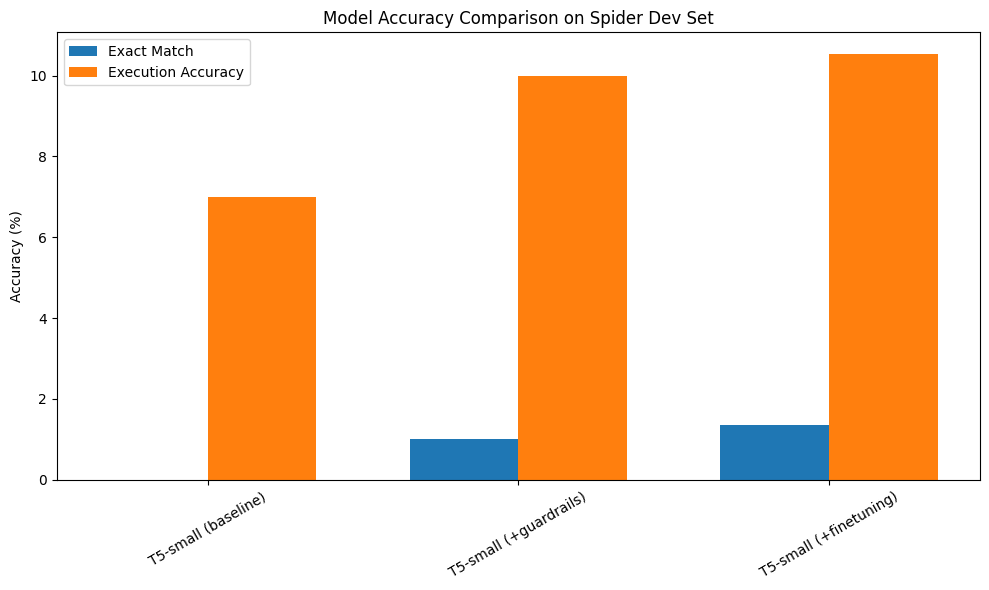

In [ ]:
models = {
    "T5-small (baseline)": "/content/drive/MyDrive/175/outputs/preds_B_t5small.jsonl",
    "T5-small (+guardrails)": "/content/drive/MyDrive/175/outputs/t5small_B_updated_preds.jsonl",
    "T5-small (+finetuning)": "/content/drive/MyDrive/175/outputs/t5_preds_direct.jsonl",
    #"Gemma 2B IT (zero-shot)": "/content/drive/MyDrive/175/outputs/gemma2bIT_output.json",
    #"Gemma 2B IT (LoRA)": "/content/drive/MyDrive/175/outputs/gemma_lora_dev_predictions.json"
}

plot_model_accuracy_comparison(
    model_dict=models,
    spider_base_path="/content/drive/MyDrive/175/spider_data"
)